# Evaluation of the Centrality Algorithm, PageRank

The algorithm and benchmark code are in the `pagerank` package under `src/`. This notebook runs them and discusses the results.

```bash
pip install -e .[report]
```

## Introduction

[1]The trillion dollar algorithm called, $PageRank(PR)$, is used in Google Search to rank web pages that Google's founders Sergey Brin and Larry Page developed in 1998. The PageRank algorithm measures the importance of a webpage by analyzing the quantity and quality of the links that point to it. The PR is an important member of centrality algorithms, graph algorithms. They identify the important nodes in a given graph and those nodes are defined as vertices with many direct or indirect connections. $PageRank(PR)$ finds most important vertices of a graph by analyzing the direct influence of nodes based on proportional rank.
 
In this notebook, we will demonstrated about the concepts of PageRank algorithm and its theoretical and empirical complexity.

This notebook demonstrates:
- The Concept of PageRank algorithm
- Implementation the PageRank algorithm and explore it on various graphs generated from Networks, python library.
- Measuring the PR complexity theoretically
- Measuring the PR complexity empirically
- PR algorithm and adjusting limitations

## The PageRank Algorithm

[2]The PageRank algorithm gives each page a rating of its importance, which is a recursively defined measure where by a page becomes important if important pages link to it. The page rank of any page is the probability that the random surfer will land on a particular page that the surfer is more likely to end up in important pages.

The page rank of any page is the probability that the random surfer will land on a particular page that the surfer is more likely to end up in important pages. The behavior of the random surfer is an example of a Markov process, which depends only of the current state of a system. The algorithm moves moves from state to state, based on probability distribution of the likelihood of moving from each state to every other possible state. 

### PageRank Mathematical Formula

The PageRank relies on an arbitrary probability distribution in which a person randomly clicks on links will arrive at any particular page. The probability which a person independently will continue is a damping factor $d$. PR computations require iterations through a number of pages to adjust approximate PR values to the theoretical value. The pageRank equation iteratively updates a candidate solution (rank) and arrive (converges) at an approximate solution to the same equation.

> <br>
>
> let $G = (V, E)$ be a directed graph with the set of vertices $V$ and set of edges $E$, where $E$ is subset of $V$ x $V$.
>  <br>
> Then The iteration equation of the page rank value of  $(V_i)$  is given by:
>
>$PR(V_i)$ = $(1 - d)$ + $d$ * $\sum_{n=In(Vi)}^{} PR(Vn) \over |Out(Vn)|$ <br>
<br>
> = $(1 - d)$ + $PR(V_1) \over Out(V_1)$ + ... + $PR(V_n) \over Out(V_n)$ 
>
> <br>

>   <br>
> where,
>
>- $In(V_i)$ be predecessors, set of vertices point to it; node (page) $(V_i)$ has nodes $(V_i)$ to $(V_n)$ point to it
>- $Out(V_i)$ be successors, the set of vertices that vertex $(V_i)$ points to; defined as the number of links going out of page $V$
>- $d$ is a damping factor which can be set between 0 (inclusive) and 1 (exclusive)
>- $\frac{d}{n}$ denotes random walk score
>   <br>
>   <br>

[1]The result of $PR(V_i)$ 0.4 for instance, means there is 40% chance that a person randomly surf will be directed to the node. The implementation of the classic PageRank algorithm uses an iterative method. At each iteration step, the PageRank value of all nodes in the graph are computed.

## PageRank Challenges


### Limitations of the Early PageRank 

In the early PageRank, there limitations:
- [5]Rank Sinks: A rank sink occurs when a page does not link out. Rank sinks occurs when by refusing to share. 

- [5]Hoarding: a group of pages that only link between each other will also monopolize PageRank, creating error. 

- [5]Circular references: A couple of pages that only link between themselves and do not link to any other page. The iterative process will never converge, creating infinity loop.

### Adjustment for PR limitations

#### First adjustment: Stochasticity Adjustment
[5]The PageRank equation computation requires summations which takes more computation time. To save the time, we can uses matrices to convert summations n to simpler vector-matrix multiplication, which saves computation time. Matrices also take advantage of matrix algebra and Markov Chains theory. The value (0 or 1) indicates whether or not there is a link between the pages. Instead of using 1 to indicate a link, we use 1/x, where x is the number of non-zero elements in each row. This strategy turns the non-zero values into probabilities, and creates a row substochastic matrix. When we add the values of each row, some of the totals will equal 1 and the rest will equal zero. The zero totals happen because of the dangling nodes or rank sinks. For a row stochastic matrix all the rows must add up to 1. Leaving the matrix unmodified does not guarantee that the values will converge during iterations. The first adjustment replaces all zero rows (dangling nodes/rank sinks) with 1/n eT (eT is a row vector of all 1s), making the matrix stochastic.

#### Second adjustment: Primitivity Adjustment
[14]Applying the Power Method to a Markov matrix converges to a unique solution if the matrix is stochastic, irreducible, and irregular. The primitive adjustment can be thought of as a random surfer. A proportion of the time the user will be following links at random and a proportion of the time the user visits new URL in stead of going to following links. In order to model this mathematically, d (damping factor), it means that 85% of the time the surfer is following links at random, and 15% of the time he is entering new URLs in the browser bar. A new matrix is used for this adjustment and random surfer is uniform.


For each node take the difference in PR score between the current iteration and the last iteration, if this error falls below a certain point the graph has converged. Starting from arbitrary values assigned to each node in the graph, the computation iterates until convergence below a given threshold is achieved.

[6]Convergence is achieved when the error rate for any vertex in the graph falls below a given threshold value. The error rate of a vertex computed by difference between the “real” score of the vertex PR(Vi) and the score computed at iteration I, PR^I(Vi) . The error rate is approximated at PR^(I+1)(Vi)+ PR^(I)(Vi). The computation of PR has no issue, if disregard scales. As damping factor increases, the rate of convergence also increases.


## Implementation

### Assumptions
- Damping factor $d = 0.85$, at most 100 iterations, tolerance $10^{-6}$.
- PageRank is defined on directed graphs. An **undirected** input is converted to a directed graph with one edge in each direction (`G.to_directed()`).
- Teleport (personalization) vector and dangling-node redistribution are both uniform, $1/n$.
- Edge weights are read from the `weight` attribute (default 1); pass `weight=None` to ignore them.
- Power iteration may not converge within the iteration budget. The result carries a `converged` flag and the last iterate is returned either way.

### Algorithm
1. Convert to a directed graph and row-normalise out-edge weights (right-stochastic matrix).
2. Initialise every node's rank to $1/n$.
3. Repeat up to `max_iter` times:
   1. Stochasticity adjustment: collect the rank of dangling nodes and spread it uniformly.
   2. For every edge $u \to v$ add $d \cdot PR(u) \cdot w_{uv}$ to $PR'(v)$.
   3. Primitivity adjustment: add the teleport mass $(1-d)/n$ to every node.
   4. Stop when $\sum_v |PR'(v) - PR(v)| < n \cdot tol$.
4. Return the scores, iteration count, convergence flag and final error.

### Parameters

| Argument | Type | Comment |
|---|---|---|
| `G` | `nx.Graph` / `nx.DiGraph` | input graph; undirected graphs become bidirectional |
| `d` | float | damping factor in $[0,1)$; default 0.85 |
| `max_iter` | int | maximum power-iteration steps; default 100 |
| `tol` | float | convergence threshold, compared against $n \cdot tol$; default $10^{-6}$ |
| `weight` | str or None | edge attribute holding the weight; default `"weight"` |

Two implementations are provided: `pagerank` (pure Python, dictionaries) and `pagerank_sparse` (SciPy CSR matrix-vector products). The analysis below is for the pure Python one.

In [1]:
import inspect

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from pagerank import pagerank, pagerank_sparse, sample_graphs, SAMPLE_GRAPHS
from pagerank.benchmark import run_benchmark, fit_power_law

%matplotlib inline

In [2]:
print(inspect.getsource(pagerank))

def pagerank(
    G: nx.Graph,
    d: float = 0.85,
    max_iter: int = 100,
    tol: float = 1.0e-6,
    weight: Optional[str] = "weight",
) -> PageRankResult:
    """Compute PageRank with pure-Python power iteration.

    Args:
        G: Any NetworkX graph. Undirected graphs are treated as directed with
           an edge in each direction.
        d: Damping factor — probability of following a link rather than
           teleporting. Must be in ``[0, 1)``.
        max_iter: Maximum number of power-iteration steps.
        tol: Convergence threshold. Iteration stops when the L1 change of the
             score vector is below ``n * tol``.
        weight: Edge attribute used as edge weight, or ``None`` to treat every
                edge as weight 1.

    Returns:
        A :class:`PageRankResult`. If the method did not converge within
        ``max_iter`` steps the last iterate is still returned with
        ``converged=False`` — it is never silently dropped.

    Complexity (per ca

## Convergence Test

Six graphs of different families from NetworkX. For each we run our implementation and compare against `networkx.pagerank` as an independent reference.

| Notation | Graph | Comment |
|---|---|---|
| G1 | path graph | linearly connected nodes; `nx.DiGraph(nx.path_graph(36))` |
| G2 | scale-free directed graph | `nx.scale_free_graph(36, seed=0)` |
| G3 | Margulis–Gabber–Galil expander | 8-regular undirected multigraph on $6^2$ nodes; `nx.margulis_gabber_galil_graph(6)` |
| G4 | Zachary's karate club | weighted social network, 34 nodes |
| G5 | Davis Southern women | bipartite social network, 32 nodes |
| G6 | Florentine families | marriage network, 15 nodes |

In [3]:
rows = []
for name, G in sample_graphs().items():
    r = pagerank(G)
    ref = nx.pagerank(G)
    rows.append({
        'graph': name,
        'directed': G.is_directed(),
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'iterations': r.iterations,
        'converged': r.converged,
        'final L1 error': r.error,
        'max |ours - networkx|': max(abs(r.scores[v] - ref[v]) for v in G),
    })
pd.DataFrame(rows).set_index('graph')

,directed,nodes,edges,iterations,converged,final L1 error,max |ours - networkx|
graph,,,,,,,
G1 path,True,36,70,46,True,0.000031,6.938894e-18
G2 scale-free,True,36,77,10,True,0.000015,1.110223e-16
G3 margulis-gabber-galil,False,36,144,9,True,0.000027,6.938894e-18
G4 karate,False,34,78,20,True,0.000030,2.775558e-17
G5 davis,False,32,89,56,True,0.000028,1.387779e-17
G6 florentine,False,15,20,35,True,0.000013,2.775558e-17


All six converge within 100 iterations and the scores agree with NetworkX to machine precision. The number of iterations depends on the graph, not on its size. The path graph and the bipartite Davis graph mix slowly because the second eigenvalue of their transition matrix is close to 1, while the expander G3 converges in under 10 iterations.

In [4]:
r = pagerank(nx.karate_club_graph())
r.top(5)

[(33, 0.09698041880501743),
 (0, 0.08850807396280011),
 (32, 0.07592643687005646),
 (2, 0.06276686454603018),
 (1, 0.05741484049711006)]

## Theoretical Analysis

Let $n = |V|$, $m = |E|$ and $I$ the number of iterations actually performed.

### Time
- `to_directed` and `stochastic_graph`: one pass over nodes and edges, $O(n + m)$.
- Initialising the rank vector and finding dangling nodes: $O(n)$.
- Each iteration walks every adjacency list once, so every edge is touched once, plus an $O(n)$ pass to add the dangling and teleport mass and compute the error. That is $O(n + m)$ per iteration.

$$T(n, m, I) = O(n + m) + O(I \cdot (n + m)) = O(I \cdot (n + m))$$

$O(I \cdot n^2)$ is reached only for a dense graph with $m = \Theta(n^2)$. The graphs studied here are sparse, $m = \Theta(n)$, so the cost is linear in $n$.

### Space
The stochastic copy of the graph is $O(n + m)$ and the two rank vectors are $O(n)$, so the total is $O(n + m)$. The sparse implementation stores a CSR matrix, also $O(n + m)$.

### Iterations
Power iteration converges geometrically at rate $|\lambda_2| \le d$, so $I = O\big(\log(1/\epsilon) / \log(1/d)\big)$ in the worst case. This does not depend on $n$.

## Empirical Time Complexity

For each generator we build graphs with $n \in \{25, 50, \dots, 1600\}$ nodes and constant average degree, so $m \propto n$. Each graph is timed several times and the minimum is kept. The time is divided by the number of iterations to get the per-iteration cost, and a power law $t = c \, n^k$ is fitted in log-log space.

In [5]:
sizes = [25, 50, 100, 200, 400, 800, 1600]
df = pd.DataFrame(run_benchmark(sizes=sizes, repeats=3))
df['sec_per_iter'] = df['seconds'] / df['iterations']
df.head(8)

,generator,algorithm,n,m,iterations,converged,seconds,sec_per_iter
0,path,python,25,48,50,True,0.004915,0.000098
1,path,sparse,25,48,50,True,0.001654,0.000033
2,path,python,50,98,42,True,0.003375,0.000080
3,path,sparse,50,98,42,True,0.000834,0.000020
4,path,python,100,198,33,True,0.005504,0.000167
5,path,sparse,100,198,33,True,0.000745,0.000023
6,path,python,200,398,25,True,0.008645,0.000346
7,path,sparse,200,398,25,True,0.000711,0.000028


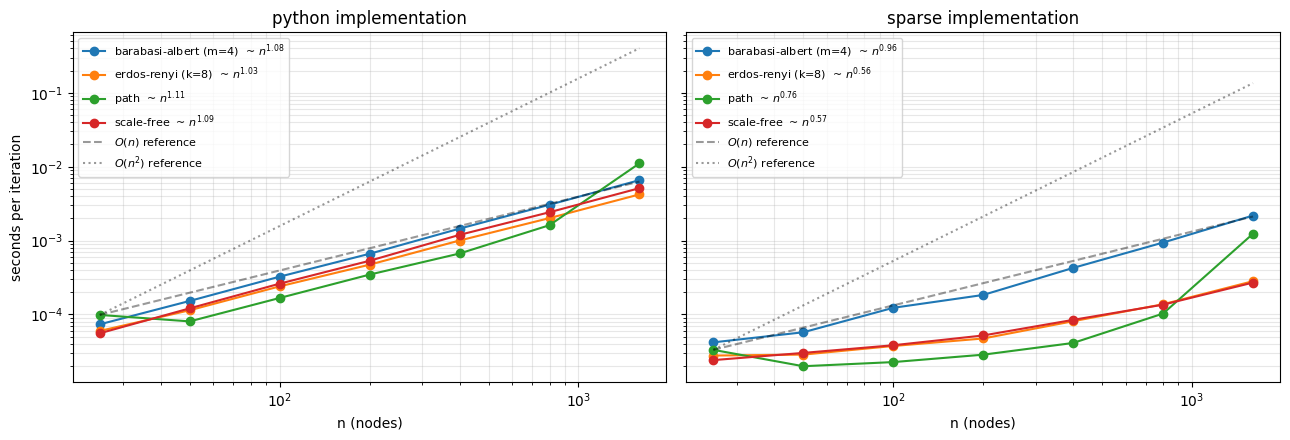

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, algo in zip(axes, ['python', 'sparse']):
    sub = df[df.algorithm == algo]
    for gname, g in sub.groupby('generator'):
        k, c = fit_power_law(g.n, g.sec_per_iter)
        ax.loglog(g.n, g.sec_per_iter, 'o-', label=f'{gname}  ~ $n^{{{k:.2f}}}$')
    ref_n = np.array(sizes, dtype=float)
    base = sub.sec_per_iter.iloc[0]
    ax.loglog(ref_n, base * ref_n / ref_n[0], 'k--', alpha=.4, label='$O(n)$ reference')
    ax.loglog(ref_n, base * (ref_n / ref_n[0])**2, 'k:', alpha=.4, label='$O(n^2)$ reference')
    ax.set_title(f'{algo} implementation')
    ax.set_xlabel('n (nodes)')
    ax.grid(True, which='both', alpha=.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel('seconds per iteration')
plt.tight_layout()

In [7]:
fits = (df.groupby(['algorithm', 'generator'])
          .apply(lambda g: pd.Series(dict(zip(['k', 'c'], fit_power_law(g.n, g.sec_per_iter)))), include_groups=False)
          )
fits.assign(k=fits.k.round(2), c=fits.c.map('{:.2e}'.format))

k         c
algorithm generator                            
python    barabasi-albert (m=4)  1.08  2.22e-06
          erdos-renyi (k=8)      1.03  2.10e-06
          path                   1.11  1.32e-06
          scale-free             1.09  1.71e-06
sparse    barabasi-albert (m=4)  0.96  1.46e-06
          erdos-renyi (k=8)      0.56  3.28e-06
          path                   0.76  1.03e-06
          scale-free             0.57  3.13e-06

For the pure Python implementation the fitted exponent is between 1.0 and 1.3 for every generator, which matches $O(I \cdot (n+m))$ with $m \propto n$. The sparse implementation is 5 to 20 times faster. At these sizes most of its time goes to building the CSR matrix rather than iterating, which is why its slope is below 1.

### Total time on the sample graphs

,seconds,iterations,n+m,sec_per_iter_per_(n+m)
graph,,,,
G2 scale-free,0.000878,10,113,7.772124e-07
G6 florentine,0.000900,35,35,7.349657e-07
G4 karate,0.001541,20,112,6.877978e-07
G3 margulis-gabber-galil,0.002080,9,180,1.283977e-06
G1 path,0.002393,46,106,4.907539e-07
G5 davis,0.003977,56,121,5.868813e-07


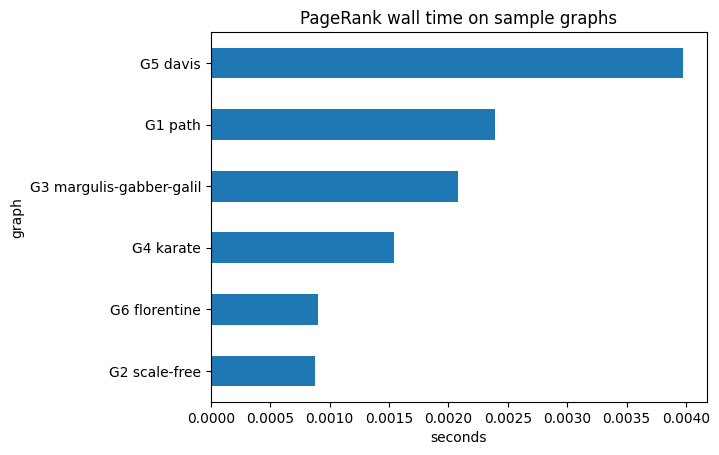

In [8]:
tot = pd.DataFrame([
    {'graph': name, 'seconds': min(__import__('timeit').repeat(lambda: pagerank(G), number=1, repeat=5)),
     'iterations': pagerank(G).iterations, 'n+m': G.number_of_nodes() + G.number_of_edges()}
    for name, G in sample_graphs().items()
]).set_index('graph').sort_values('seconds')
tot['sec_per_iter_per_(n+m)'] = tot.seconds / tot.iterations / tot['n+m']
ax = tot['seconds'].plot.barh(title='PageRank wall time on sample graphs')
ax.set_xlabel('seconds')
tot

After dividing by the iteration count and by $n + m$, the cost per edge per iteration is about the same for all six graphs. The differences in wall time come from the number of iterations each graph needs.

## Conclusion

PageRank measures the relative importance of a page as the stationary distribution of a random surfer on the link graph. The stochasticity and primitivity adjustments make that distribution well defined.

We implemented the algorithm, checked it against NetworkX on six graphs, and analysed its cost. Power iteration runs in $O(I \cdot (n + m))$ time and $O(n + m)$ space. On sparse graphs with $m \propto n$ the measured per-iteration time grows as $n^{1.0}$ to $n^{1.3}$. The number of iterations depends on the spectral gap of the graph, not on its size.

## References


[1]Wikipedia Contributors, PageRank, Wikipedia. (2022).<br> https://en.wikipedia.org/wiki/PageRank (accessed July 24, 2022).<br>
<br>
[2]Graph generators — NetworkX 2.8.5 documentation, Networkx.org. (2019).<br> https://networkx.org/documentation/stable/reference/generators.html (accessed July 24, 2022).<br>
<br>
[3]pagerank — NetworkX 2.8.5 documentation, Networkx.org. (2022).<br> https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html (accessed July 24, 2022).<br>
<br>
[4]L. Page, S. Brin, R. Motwani, T. Winograd, The PageRank Citation Ranking: Bringing Order to the Web. - Stanford InfoLab Publication Server, Stanford.edu. (1999).<br> https://doi.org/http://ilpubs.stanford.edu:8090/422/1/1999-66.pdf.<br>
<br>
[5]E. Guven, module05_ds, Jhu.edu. (2022).<br> https://jhu.instructure.com/courses/13110/pages/module-5-readings?module_item_id=1077894 (accessed July 24, 2022).<br>

[6]R. Mihalcea, P. Tarau, TextRank: Bringing Order into Texts, n.d.<br> https://digital.library.unt.edu/ark:/67531/metadc30962/m2/1/high_res_d/Mihalcea-2004-TextRank-Bringing_Order_into_Texts.pdf.

[7]
path_graph — NetworkX 2.8.5 documentation, Networkx.org. (2022).<br> https://networkx.org/documentation/stable/reference/generated/networkx.generators.classic.path_graph.html#networkx.generators.classic.path_graph (accessed July 26, 2022).<br>

[8]
path_graph — NetworkX 2.8.5 documentation, Networkx.org. (2022).<br> https://networkx.org/documentation/stable/reference/generated/networkx.generators.classic.path_graph.html#networkx.generators.classic.path_graph (accessed July 26, 2022).<br>

[9]
scale_free_graph — NetworkX 2.8.5 documentation, Networkx.org. (2022). https://networkx.org/documentation/stable/reference/generated/networkx.generators.directed.scale_free_graph.html (accessed July 26, 2022).<br>

[10]
karate_club_graph — NetworkX 2.8.5 documentation, Networkx.org. (2022).<br> https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html#networkx.generators.social.karate_club_graph (accessed July 26, 2022).<br>

[11]
karate_club_graph — NetworkX 2.8.5 documentation, Networkx.org. (2022).<br> https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html#networkx.generators.social.karate_club_graph (accessed July 26, 2022).<br>

[12]
davis_southern_women_graph — NetworkX 2.8.5 documentation, Networkx.org. (2022)<br>. https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.davis_southern_women_graph.html (accessed July 26, 2022).<br>

[13]
florentine_families_graph — NetworkX 2.8.5 documentation, Networkx.org. (2022).<br> https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.florentine_families_graph.html (accessed July 26, 2022).<br>

[14]
B. Ali, School of Education, Culture and Communication Division of Applied Mathematics MASTER (1 YEAR) THESIS IN MATHEMATICS / APPLIED MATHEMATICS<br> A comparison of a Lazy PageRank and variants for common graph structures, n.d.<br> https://mdh.diva-portal.org/smash/get/diva2:1179590/FULLTEXT01.pdf.<br>

    
